<a href="https://colab.research.google.com/github/jolineuichanco/DataAnalytics/blob/main/demos/Week06_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 6 Demo**


In [1]:
import pandas as pd

data_dict = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Sales': [102, 110, 112, 115, 117, 116, 118, 129, 123, 120, 129, 133],
    'Ad_Dollars': [5.5, 5.8, 6.0, 5.8, 6.2, 6.3, 6.5, 7.0, 6.5, 6.4, 6.7, 6.8]
}

df = pd.DataFrame(data_dict)
df.head()

,Month,Sales,Ad_Dollars
0,Jan,102,5.5
1,Feb,110,5.8
2,Mar,112,6.0
3,Apr,115,5.8
4,May,117,6.2


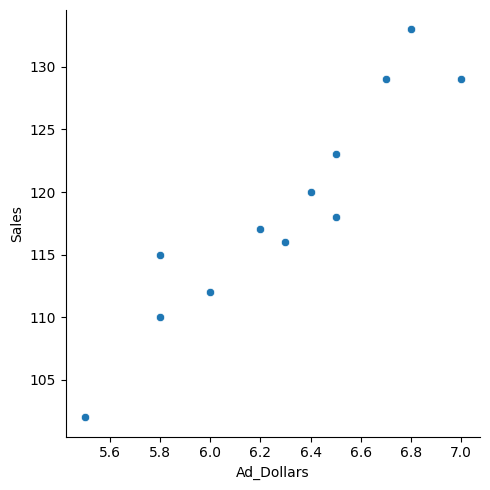

In [2]:
import seaborn as sns
sns.relplot(data=df, x='Ad_Dollars', y='Sales', kind='scatter')

## Sklearn

In [5]:
from sklearn.linear_model import LinearRegression

# create an instance of the LinearRegression class
reg = LinearRegression()

# Note the double square brackets for the "X"
# (because you can have multiple columns in X)
reg.fit(df[['Ad_Dollars']], df['Sales'])

# Get the slope and intercept from the fitted model
slope = reg.coef_[0]
intercept = reg.intercept_

print("Fitted line has slope " + str(slope))
print("Fitted line has intercept " + str(intercept))

Fitted line has slope 18.42242990654205
Fitted line has intercept 2.7588785046729356


In [ ]:
import seaborn as sns
sns.regplot(data=df, x='Ad_Dollars', y='Sales')

In [6]:
from sklearn.metrics import r2_score

y_actual = df['Sales']
y_predict = reg.predict(df[['Ad_Dollars']])

# Compute the R2 score based on actual and predicted y values
r2 = r2_score(y_actual, y_predict)
print(f"R-squared score: {r2}")

R-squared score: 0.8790253154477075


## Statsmodels using formulas

In [7]:
import statsmodels.formula.api as smf

# Fit regression model using formula
model = smf.ols("Sales ~ Ad_Dollars", data=df)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     72.66
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           6.73e-06
Time:                        19:49:41   Log-Likelihood:                -29.991
No. Observations:                  12   AIC:                             63.98
Df Residuals:                      10   BIC:                             64.95
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7589     13.629      0.202      0.8

## Checking Assumptions

In [ ]:
# Load data
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/HistData/Guerry.csv"
dat = pd.read_csv(url)
dat.head()

In [ ]:
import statsmodels.formula.api as smf
import numpy as np

# Fit regression model (using the natural log of one of the regressors)
model = smf.ols("Lottery ~ Literacy + np.log(Pop1831)", data=dat)
results = model.fit()

# Calculate fitted values for the current model (results from 'dat')
fitted = results.fittedvalues

# residuals
residuals = results.resid

# Inspect the results
print(results.summary())

In [ ]:
import seaborn as sns
sns.histplot(residuals, bins=15)

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(results.resid, line='s')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot residuals against fitted values to check for heteroskedasticity
# Goal: Residuals should be randomly scattered around zero with no clear pattern (e.g., no 'megaphone' shape)
sns.residplot(x=fitted, y=residuals, lowess=True)

In [ ]:
from statsmodels.stats.outliers_influence import OLSInfluence
import matplotlib.pyplot as plt

# Calculate Cook's distance
cook_distance = OLSInfluence(results).cooks_distance[0]

# Plot Cook's distance
plt.stem(cook_distance, markerfmt=",")
plt.xlabel('Observation Index')
plt.ylabel('Cook\'s Distance')
plt.title('Cook\'s Distance Plot')

# Add a reference line for potential cutoff (e.g., 4 / n or 1)
n = len(dat) # Number of observations
plt.axhline(y=4/n, color='red', linestyle='--', label=f'Threshold (4/n = {4/n:.3f})')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot residuals vs. Literacy
plt.figure(figsize=(10, 3.5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.residplot(x=dat['Literacy'], y=residuals, lowess=True)
plt.xlabel('Literacy')
plt.ylabel('Residuals')
plt.title('Residuals vs. Literacy')

# Plot residuals vs. log(Pop1831)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.residplot(x=dat['Pop1831'].apply(np.log), y=residuals, lowess=True)
# lowess line shows the local average of teh residuals
plt.xlabel('log(Pop1831)')
plt.ylabel('Residuals')
plt.title('Residuals vs. log(Pop1831)')

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Get the exogenous variables (predictors) from the model
# 'model.exog' contains the predictors, including the constant
x_vars = results.model.exog
num_vars = x_vars.shape[1]

for i in range(num_vars):
  vif = variance_inflation_factor(x_vars, i) #returns VIF_i
  print('VIF for ' + results.model.exog_names[i] + " is: " + str(vif))

# **In-Class Prediction Session 1**

In [8]:
import pandas as pd

# Corrected URL to raw CSV data
url = 'https://raw.githubusercontent.com/jolineuichanco/DataAnalytics/main/challenges/week2/zagat.CSV'
df = pd.read_csv(url)

df.head()

,Name,Food,Decor,Service,Price
0,107 West,16,13,16,26
1,2nd Street cafe,14,13,15,21
2,44 & Hell's kitchen,22,19,19,42
3,55 wall,21,22,21,54
4,55 wall street,21,22,21,54


Please do the following:


1.   Build a linear model using "Food" as predictor and "Price" as a response
2.   Build a linear model using "Food" and "Decor" as predictors and "Price" as a response.
3.   Build a linear model using "Food", "Decor" and "Service" as predictors and "Price" as a response.

Which is the best model for predicting price?


In [9]:
import statsmodels.formula.api as smf
model = smf.ols("Price ~ Food", data=df)

results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     121.3
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           6.74e-24
Time:                        20:31:43   Log-Likelihood:                -1183.9
No. Observations:                 300   AIC:                             2372.
Df Residuals:                     298   BIC:                             2379.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.4610      3.882     -1.407      0.1

In [10]:
import statsmodels.formula.api as smf
model = smf.ols("Price ~ Food + Decor", data=df)

results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     318.2
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.41e-74
Time:                        20:32:04   Log-Likelihood:                -1063.4
No. Observations:                 300   AIC:                             2133.
Df Residuals:                     297   BIC:                             2144.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -18.1864      2.686     -6.771      0.0

In [11]:
import statsmodels.formula.api as smf
model = smf.ols("Price ~ Food + Decor + Service", data=df)

results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     342.8
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           6.07e-96
Time:                        20:32:17   Log-Likelihood:                -1010.4
No. Observations:                 300   AIC:                             2029.
Df Residuals:                     296   BIC:                             2044.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -21.1952      2.271     -9.334      0.0

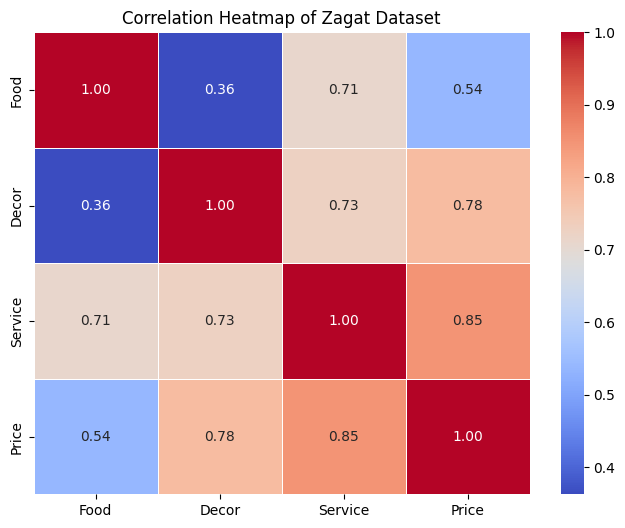

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation calculation
numerical_df = df[['Food', 'Decor', 'Service', 'Price']]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Zagat Dataset')
plt.show()

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Get the exogenous variables (predictors) from the model
# 'model.exog' contains the predictors, including the constant
x_vars = results.model.exog
num_vars = x_vars.shape[1]

for i in range(num_vars):
  vif = variance_inflation_factor(x_vars, i) #returns VIF_i
  print('VIF for ' + results.model.exog_names[i] + " is: " + str(vif))

VIF for Intercept is: 30.958959474557535
VIF for Food is: 2.2380221950056205
VIF for Decor is: 2.351227544759706
VIF for Service is: 4.114524242403408


# **In-Class Prediction Session 2**

In [15]:
import pandas as pd

url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/mtcars.csv"
mtcars = pd.read_csv(url, index_col=0)

# Display the first few rows
mtcars.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


Please do the following:


1.   Investigate the relationship between "mpg" and "hp" using a scatterplot
2.   Display the summary statistics.
3.   Estimate the linear model to predict "hp" using "mpg"
4.   Plot the scatterplot with the regression line
5.   Perform residual diagnostics by plotting the residuals against the predictor.



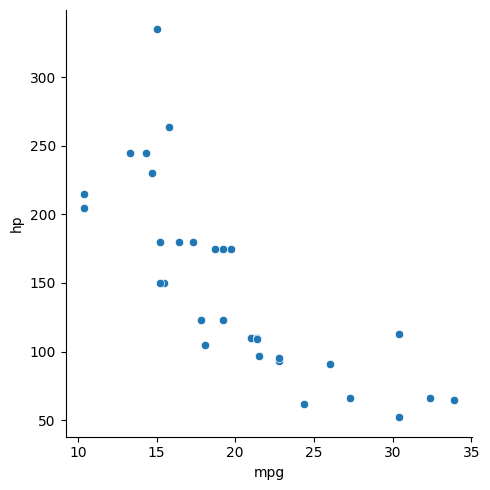

In [36]:
import seaborn as sns
sns.relplot(data=mtcars, x='mpg', y='hp', kind='scatter')

In [37]:
mtcars[['mpg', 'hp']].describe()

,mpg,hp
count,32.000000,32.000000
mean,20.090625,146.687500
std,6.026948,68.562868
min,10.400000,52.000000
25%,15.425000,96.500000
50%,19.200000,123.000000
75%,22.800000,180.000000
max,33.900000,335.000000


In [21]:
import statsmodels.formula.api as smf

model = smf.ols('hp ~ mpg', data=mtcars)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     hp   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     45.46
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.79e-07
Time:                        20:55:16   Log-Likelihood:                -165.43
No. Observations:                  32   AIC:                             334.9
Df Residuals:                      30   BIC:                             337.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    324.0823     27.433     11.813      0.0

<Axes: xlabel='mpg', ylabel='hp'>

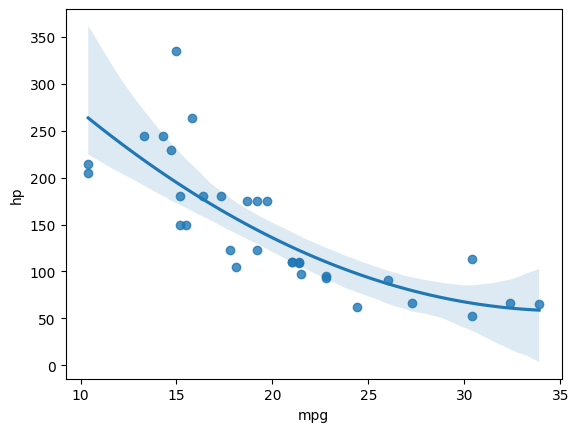

In [40]:
import seaborn as sns

sns.regplot(data=mtcars, x='mpg', y='hp', order=2)

<Axes: xlabel='mpg'>

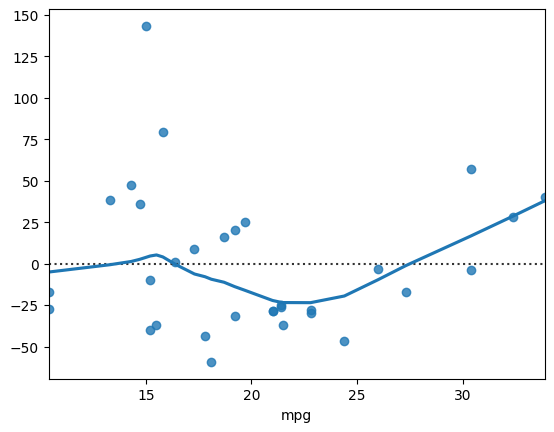

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate residuals from the previously fitted model
residuals = results.resid

# Plot residuals against the predictor (mpg)
sns.residplot(x=mtcars['mpg'], y=residuals, lowess=True)


In [32]:
mtcars['mpg_squared'] = mtcars['mpg']**2
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_squared
rownames,,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,441.00
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,441.00
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,519.84
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,457.96
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,349.69


In [33]:
import statsmodels.formula.api as smf

model_mpg_squared = smf.ols('hp ~ mpg_squared', data=mtcars)
results_mpg_squared = model_mpg_squared.fit()

print(results_mpg_squared.summary())

                            OLS Regression Results                            
Dep. Variable:                     hp   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     35.19
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.69e-06
Time:                        20:58:38   Log-Likelihood:                -167.77
No. Observations:                  32   AIC:                             339.5
Df Residuals:                      30   BIC:                             342.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     229.0458     16.206     14.133      